In [1]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
from scipy.special import factorial
from scipy.stats import binned_statistic
from matplotlib.ticker import ScalarFormatter
import sys

In [2]:
sys.path.append(r"C:\Users\xylin\Documents\Researches\multiphonon-direct-detection\StructureFactor1D.py")
from StructureFactor1D import StructureFactor1D
# from StructureFactor1D import StructureFactor1D_NIndepDW

In [3]:
# Moved to StructureFactor1D.py script 

# class StructureFactor1DCoherent(StructureFactor1D_NIndepDW):
#     ######## Public ########

#     def init_recursion(self): 
#         self.sOrder = 1
#         print(f'Processing n = {self.sOrder}...')
#         self._s_diag_init()
#         self._c_offdiag_init()

#     def update_s_factor(self):
#         '''
#         Update the integrated diagonal s factor (both diagonal and off diagonal) using the recursive relation.
#         '''
#         self.sOrder += 1
#         print(f'Processing n = {self.sOrder}...')
#         # update diagonal term
#         newOmega, newS = self._calc_s_diag_rec()
#         self.currIntS_diag = self._integrate_s_diag(newOmega, newS)
#         # update off diagonal term
#         newOmega, newC = self._calc_c_offdiag_rec()
#         self.currIntC_offdiag = self._integrate_c_offdiag(newOmega, newC)

#     def get_binned_s_offdiag(self, xlist, delta_omega):
#         # sum over c_ll' to get s factor
#         mult = (self.nLattice - self.l_diff)*np.real(self.currIntC_offdiag)
#         sfactor_sum = 2* (self.couplingConst**2) * np.sum(mult, axis=1)
#         result = binned_statistic(self._DoS_x_list, sfactor_sum, statistic="sum",bins=len(xlist), range=(min(xlist), max(xlist)))
#         ylist = result.statistic/delta_omega
#         return np.nan_to_num(ylist, nan=0.0) # cleaning up the nan

#     ######## Helper ########

#     def _c_offdiag_init(self,): # l' minus l
#         '''
#         Calculate the first c_ll' of the recursive relation. 
#         currIntC_offdiag: 2d array with shape (# of nu, # of xi)
#         '''
#         DWfactor =  np.exp(- 2 * self.getDebyeWallerConst()) 
#         offdiag_factor = np.exp(1j*(self.q_value*self.latticeConst-2*np.pi* self.nuList/self.nLattice)* self.l_diff) 
#         c_values =  2 * np.pi / self.volume * DWfactor *  (self.q_value**2 /(2*self.mass*self.nLattice)) * offdiag_factor/ self.omegaList[:,np.newaxis]
#         self.currIntC_offdiag = self._integrate_c_offdiag(self.omegaList, c_values)


#     def _integrate_c_offdiag(self,allowed_omegas, c_offdiag):
#         '''
#         Get the integrated version of c_ll'
#         '''
#         result = binned_statistic(allowed_omegas, c_offdiag.T, statistic="sum",bins=self._DoS_nBins, range=(self._DoS_min_omega, self._DoS_max_omega))
#         return result.statistic.T

#     def _calc_c_offdiag_rec(self,):
#         exp_factor = np.exp(-2j*np.pi*self.nuList*self.l_diff/self.nLattice)
#         rec_factor = exp_factor/self.omegaList[:, np.newaxis]
#         newIntC = (self.q_value**2 /(2*self.mass*self.nLattice))/self.sOrder * rec_factor[:, np.newaxis, :]*self.currIntC_offdiag
#         newOmega = self._DoS_x_list[:, np.newaxis] + self.omegaList 
#         return newOmega.T.reshape(-1,), newIntC.reshape(-1,self.l_diff.shape[0])
    


DW factor that doesn't match: $\omega_{DW} = 1/(\text{average}_\text{energy levels} \frac{1}{\omega_i})$

DW factor that does match: $\omega_{DW} = 1/(\sum_\text{energy levels} \omega_i^{-1}/ N)$

Normally these two numbers should be the same, because the number of the lattice is the same as the number of energy level. However, we use $\omega_i$> 1meV energy cut, so the first DW factor is smaller than the second DW factor, and the plots are different. 

The following calculations uses the "good" DW factor

Processing n = 1...
Plotting n = 1...
Processing n = 2...
Plotting n = 2...
Processing n = 3...
Plotting n = 3...
Processing n = 4...
Plotting n = 4...
Processing n = 5...
Plotting n = 5...
Processing n = 6...
Plotting n = 6...
Processing n = 7...
Plotting n = 7...
Processing n = 8...
Plotting n = 8...
Processing n = 9...
Plotting n = 9...
Processing n = 10...
Plotting n = 10...


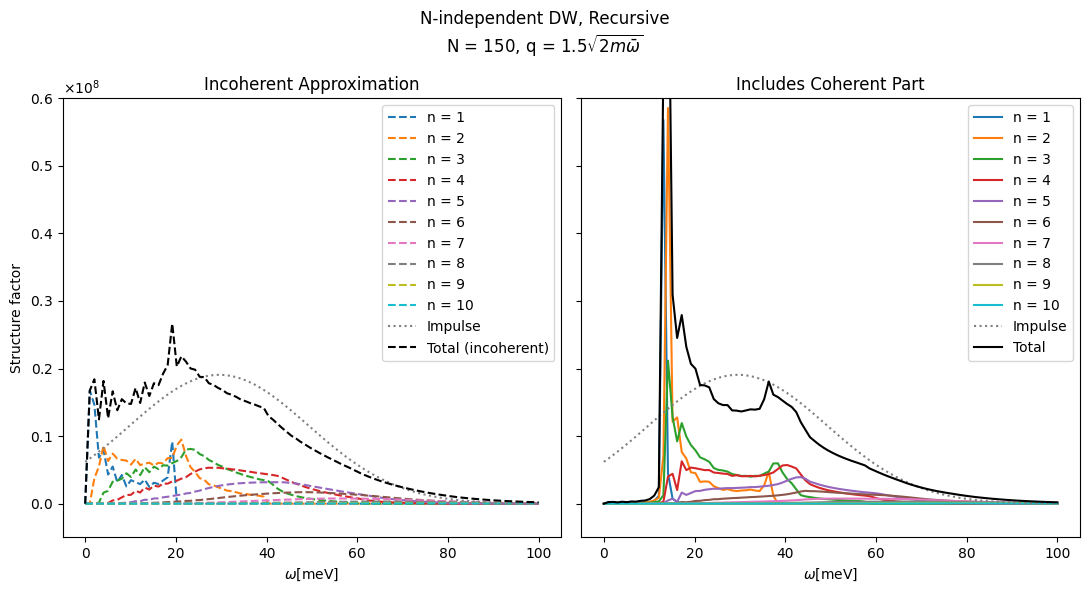

In [4]:
multplier = 1.5
q_value  = multplier*np.sqrt(2*26161e3*13.13e-6) # uses averaged omega (not inverse of averaged inverse)

xlength = 100 # length of xlist used for plotting. Also changes the size of bin 
nLattice = 150
test = StructureFactor1D(nLattice = nLattice,q_value=q_value, couplingConst=28,)
# color = ['r', 'g', 'b', 'y', 'c', 'tab:blue', 'tab:red', 'tab:yellow', "tab:brown", 'tab:purple']
max_omega = 100*1e-6 # keV
xlist, delta_omega = np.linspace(0, max_omega,xlength, retstep=True) 
nPhonon = 10

# keep track of structure factors of all orders
sfactorPerPhonon = np.empty((nPhonon, xlength))

# impulse approx
deltasq = q_value**2 * 13.13e-6/(2*test.mass)
ia =  28**2 / ((test.latticeConst**3)/4) * np.sqrt(2*np.pi/deltasq) * np.exp(- (xlist-(q_value**2/(2*test.mass)))**2 / (2*deltasq)) # uses averaged omega (not inverse of averaged inverse)

sum_diag = np.zeros(xlist.shape)
sum_offdiag = np.zeros(xlist.shape)
fig, ax = plt.subplots(figsize=(11,6), ncols=2, sharey=True)
test.setup_DoS(max_omega, nBins=1000)
test.init_recursion()
# get the binned s factor of order 1
s_diag = test.get_binned_s_diag(xlist, delta_omega)
s_offdiag = test.get_binned_s_offdiag(xlist, delta_omega)
# update the sum of s factor
sum_diag += s_diag 
sum_offdiag += s_offdiag
# plot the current s factor
print(f'Plotting n = 1...')
ax[0].plot(xlist*1e6, s_diag,label=f'n = 1',  linestyle='--') 
ax[1].plot(xlist*1e6, s_diag+s_offdiag,label=f'n = 1',) 
sfactorPerPhonon[0] = s_diag+s_offdiag 
for i in range(2,nPhonon+1):
    test.update_s_factor()
    # get the binned s factor of order i
    s_diag = test.get_binned_s_diag(xlist, delta_omega)
    s_offdiag = test.get_binned_s_offdiag(xlist, delta_omega)
    sfactorPerPhonon[i-1] = s_diag+s_offdiag
    # update the sum of s factor
    sum_diag += s_diag 
    sum_offdiag += s_offdiag
    # plot the current s factor
    print(f'Plotting n = {i}...')
    ax[0].plot(xlist*1e6, s_diag,label=f'n = {i}',  linestyle='--') 
    ax[1].plot(xlist*1e6, s_diag+s_offdiag,label=f'n = {i}',) 
    # calculate the s factor of next order
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((8,8))
ax[0].yaxis.set_major_formatter(formatter)
ax[1].yaxis.set_major_formatter(formatter)
# plot the impulse approximations
ax[0].plot(xlist*1e6, ia, linestyle=":", color="gray", label='Impulse')
ax[1].plot(xlist*1e6, ia, linestyle=":", color="gray", label='Impulse')
# plot the sum of s for all orders
ax[0].plot(xlist*1e6,sum_diag, label="Total (incoherent)",linestyle="--",color="black",)
ax[1].plot(xlist*1e6,sum_diag+sum_offdiag, label="Total",color="black",)
# labels & titles
txt1 = r"$\omega_{DW}$" #r"exp$(\frac{q^2}{4m\omega_{DW}})$"
txt2 = r"$\sqrt{2m\bar\omega}$" 
plt.ylim(-0.05e8, .6e8)
plt.suptitle(f'N-independent DW, Recursive\nN = {nLattice}, q = {multplier}{txt2}')# , {txt} = {test.omegaNaught*1e6} meV
# {txt1} = {omega_dw*1e6:.2f} meV,
ax[0].set_ylabel('Structure factor')
ax[0].set_xlabel(r'$\omega$[meV]')
ax[1].set_xlabel(r'$\omega$[meV]')
ax[0].legend()
ax[1].legend()
ax[0].set_title('Incoherent Approximation')
ax[1].set_title('Includes Coherent Part')
plt.tight_layout()
# plt.savefig(f"fullsfactorwrtomega_q{int(q_value)}_{nLattice}lattice_NindepDW_energyCut_recur_DoS", bbox_inches="tight")

## Check: $n=1$ has peak at $\omega = 2\omega_0 \sin \frac{ka}{2}$ for $k=q$

In [5]:
print("maximizer of $S$:", xlist[np.argmax(sfactorPerPhonon[0])]*1e6) 
print(r"expected $\omega_{max}$ from dispersion relation:", 2*test.omegaNaught*np.sin(q_value*test.latticeConst/2)*1e6)

maximizer of $S$: 13.13131313131313
expected $\omega_{max}$ from dispersion relation: -13.86035438598603


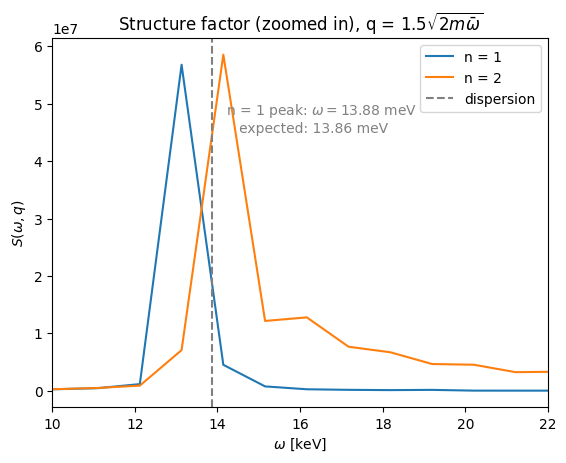

In [6]:
plt.plot(xlist*1e6,sfactorPerPhonon[0],label="n = 1")
plt.plot(xlist*1e6, sfactorPerPhonon[1], label='n = 2')
plt.axvline(np.abs(2*test.omegaNaught*np.sin(q_value*test.latticeConst/2)*1e6), linestyle='--', color="gray", label='dispersion')
plt.title(f"Structure factor (zoomed in), q = {multplier}{txt2}")
plt.text(14.2, 4.5e7, "n = 1 peak: $\omega = 13.88$ meV\n   expected: 13.86 meV", color='gray')
plt.ylabel("$S(\omega, q)$")
plt.xlabel(r"$\omega$ [keV]")
plt.xlim(10,22)
plt.legend()
# plt.savefig(f"zoomin_factorwrtomega_q{int(q_value)}_{nLattice}lattice", bbox_inches="tight")

Graph used in the paper

In [7]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'stix', 
    'font.size': 17              
})

In [8]:
def compute_structure_factors(multiplier, xlength=100, nLattice=200, nPhonon=20):
    """
    Computes the structure factors (incoherent, total, and impulse approximation)
    for a given multiplier.
    """
    q_value = multiplier * np.sqrt(2 * 26161e3 * 13.13e-6) # uses averaged omega
    
    # Initialize your custom class
    test = StructureFactor1D(nLattice=nLattice, q_value=q_value, couplingConst=28)
    
    max_omega = 150 * 1e-6 # keV
    xlist, delta_omega = np.linspace(0, max_omega, xlength, retstep=True) 
    
    # Calculate Impulse Approximation
    deltasq = q_value**2 * 13.13e-6 / (2 * test.mass)
    ia = (28**2 / ((test.latticeConst**3)/4) 
          * np.sqrt(2*np.pi/deltasq) 
          * np.exp(- (xlist-(q_value**2/(2*test.mass)))**2 / (2*deltasq)))
    
    # Setup calculation
    test.setup_DoS(max_omega, nBins=1000)
    test.init_recursion()
    
    s_diag_all = []
    s_tot_all = []
    
    sum_diag = np.zeros(xlist.shape)
    sum_offdiag = np.zeros(xlist.shape)
    
    for i in range(1, nPhonon + 1):
        if i > 1:
            test.update_s_factor()
            
        # Get the binned s factor of order i
        s_diag = test.get_binned_s_diag(xlist, delta_omega)
        s_offdiag = test.get_binned_s_offdiag(xlist, delta_omega)
        
        # Store individual nth-order arrays
        s_diag_all.append(s_diag)
        s_tot_all.append(s_diag + s_offdiag)
        
        # Update sums
        sum_diag += s_diag 
        sum_offdiag += s_offdiag

    sum_tot = sum_diag + sum_offdiag
    
    return xlist, ia, s_diag_all, s_tot_all, sum_diag, sum_tot

In [9]:
def precompute_all_data(multipliers=[1.0, 1.5, 2.5], xlength=100, nLattice=200, nPhonon=20):
    """
    Runs the calculations for all multipliers and stores them in a dictionary.
    Keys are the multipliers, values are dictionaries of the computed arrays.
    """
    all_data = {}
    for multiplier in multipliers:
        print(f"Calculating data for multiplier = {multiplier}...")
        (xlist, ia, s_diag_all, s_tot_all, 
         sum_diag, sum_tot) = compute_structure_factors(multiplier, xlength, nLattice, nPhonon)
        
        # Store the results in a nested dictionary
        all_data[multiplier] = {
            'xlist': xlist,
            'ia': ia,
            's_diag_all': s_diag_all,
            's_tot_all': s_tot_all,
            'sum_diag': sum_diag,
            'sum_tot': sum_tot
        }
    print("All calculations complete and stored in memory!")
    return all_data

In [10]:
my_computed_data = precompute_all_data(multipliers=[1.0, 1.5, 2.5])

Calculating data for multiplier = 1.0...
Processing n = 1...
Processing n = 2...
Processing n = 3...
Processing n = 4...
Processing n = 5...
Processing n = 6...
Processing n = 7...
Processing n = 8...
Processing n = 9...
Processing n = 10...
Processing n = 11...
Processing n = 12...
Processing n = 13...
Processing n = 14...
Processing n = 15...
Processing n = 16...
Processing n = 17...
Processing n = 18...
Processing n = 19...
Processing n = 20...
Calculating data for multiplier = 1.5...
Processing n = 1...
Processing n = 2...
Processing n = 3...
Processing n = 4...
Processing n = 5...
Processing n = 6...
Processing n = 7...
Processing n = 8...
Processing n = 9...
Processing n = 10...
Processing n = 11...
Processing n = 12...
Processing n = 13...
Processing n = 14...
Processing n = 15...
Processing n = 16...
Processing n = 17...
Processing n = 18...
Processing n = 19...
Processing n = 20...
Calculating data for multiplier = 2.5...
Processing n = 1...
Processing n = 2...
Processing n = 

In [39]:
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

def plot_stored_structure_factors(data_dict, nLattice=200, cmap_name='tab20', wspace=0.1, hspace=0.15):
    multipliers = list(data_dict.keys())
    ncols = len(multipliers)

    first_mult = multipliers[0]
    nPhonon = len(data_dict[first_mult]['s_diag_all'])
    fig, axes = plt.subplots(nrows=2, ncols=ncols, figsize=(13,7.3125), sharex=True, sharey=True)
    fig.subplots_adjust(wspace=wspace, hspace=hspace)

    formatter = ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((8, 8))
    txt2 = r"$\sqrt{2m\bar\omega}$"

    cmap = plt.get_cmap(cmap_name)
    colors = [cmap(i % cmap.N) for i in range(nPhonon)]

    for col, multiplier in enumerate(multipliers):
        data = data_dict[multiplier]
        xlist = data['xlist']
        ia = data['ia']
        s_diag_all = data['s_diag_all']
        s_tot_all = data['s_tot_all']
        sum_diag = data['sum_diag']
        sum_tot = data['sum_tot']

        # Row 0 = Incoherent, Row 1 = Total
        ax_incoh = axes[0, col]
        ax_tot = axes[1, col]

        for i in range(nPhonon):
            n_order = i + 1
            color = colors[i]
            ax_incoh.plot(xlist * 1e6, s_diag_all[i], label=f'$n = {n_order}$', linestyle='-', color=color)
            ax_tot.plot(xlist * 1e6, s_tot_all[i], linestyle='-', color=color)

        ax_incoh.plot(xlist * 1e6, sum_diag, label="Sum", linestyle="-", color="black")
        ax_tot.plot(xlist * 1e6, sum_tot, linestyle="-", color="black")

        ax_incoh.plot(xlist * 1e6, ia, linestyle=":", color="gray", label='Impulse')
        ax_tot.plot(xlist * 1e6, ia, linestyle=":", color="gray")

        # Titles on the top row, x-labels on the bottom row
        ax_incoh.set_title(rf'$q = ${multiplier} {txt2}')
        ax_tot.set_xlabel(r'$\omega$ [meV]')

        ax_incoh.yaxis.set_major_formatter(formatter)
        ax_tot.yaxis.set_major_formatter(formatter)

        if col == ncols - 1:
            handles, labels = ax_incoh.get_legend_handles_labels()
            ax_incoh.legend(handles, labels, bbox_to_anchor=(1.05, 1.15), loc='upper left')

    # Shared y-axis label, row identity as in-panel text
    axes[0, 0].set_ylabel(r'$S(\omega, q)$ [keV$^2$]')
    axes[1, 0].set_ylabel(r'$S(\omega, q)$ [keV$^2$]')

    box = dict(boxstyle='round', facecolor='white', edgecolor='0.7', alpha=0.8)
    axes[0, 0].text(0.54, 0.92, '       Incoherent\nApproximation', transform=axes[0, 0].transAxes,
                    ha='left', va='top', )
    axes[1, 0].text(0.4, 0.92, 'Full Structure Factor', transform=axes[1, 0].transAxes,
                    ha='left', va='top',)

    plt.ylim(-0.05e8, 0.6e8)
    plt.show()

In [37]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'stix',
    'font.size': 15,
    'figure.dpi': 200
})

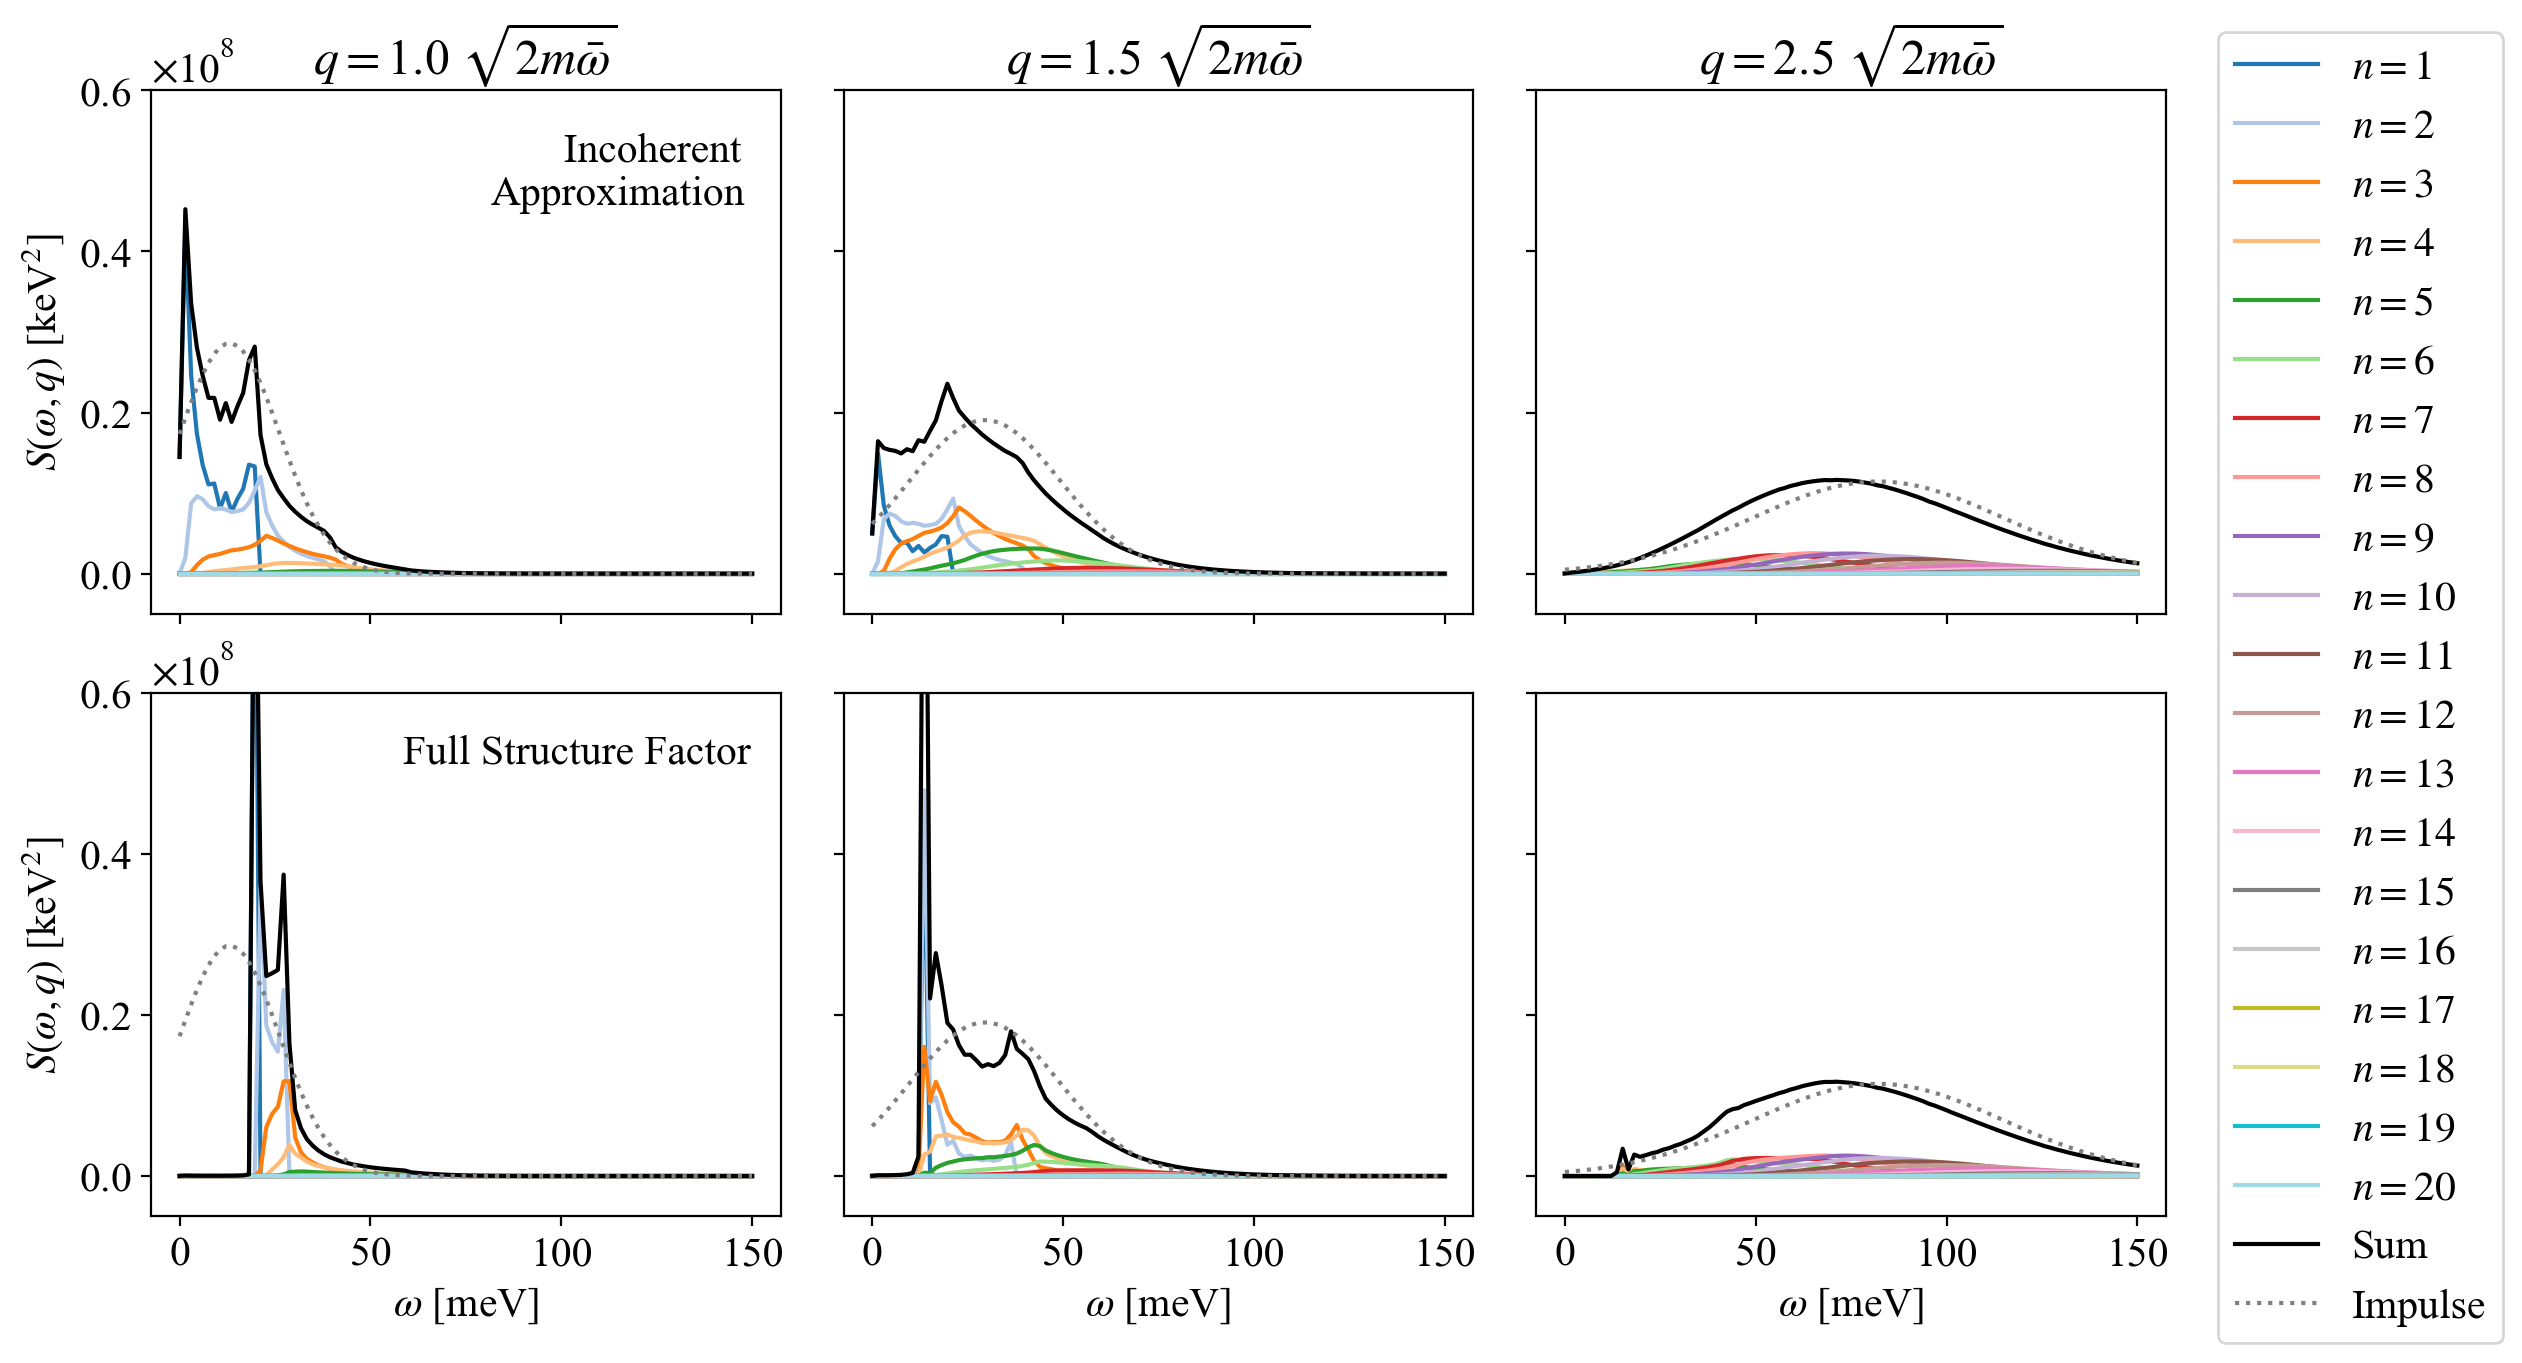

In [ ]:
plot_stored_structure_factors(my_computed_data, nLattice=200)